# Regression Using Linear Models

In [23]:
%pip install -q numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.seterr(invalid='ignore')

np.random.seed(42)

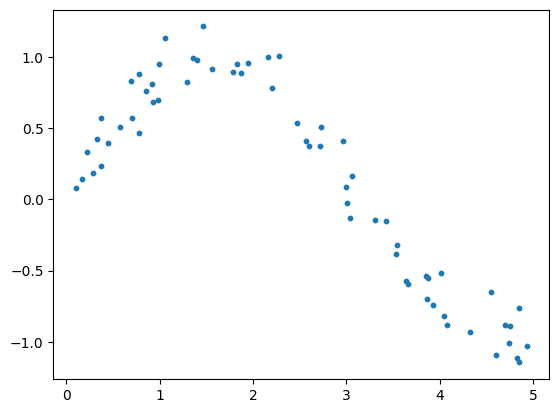

In [25]:
X = np.sort(5 * np.random.rand(80, 1), axis=0)

#.ravel() to flatten the 2D array to 1D
#generating nos from a normal distribution with mean 0 and std 0.1
#X.shape[0] i.e 80 such values to be generated
Y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Add noise to training data to simulate real world scenarios where various factors affect target values
noise = np.random.normal(0, 0.1, X.shape[0])
Y_noisy = Y + noise

X_train, X_val, Y_train, Y_val = train_test_split(X, Y_noisy, test_size=0.2, random_state=42)

# Data Preprocessing - Standardization

#create an instance of the standardscaler class
scaler = StandardScaler()

#fit transform computes mean and std from training data and standardizes it
# variance = (summation(x - mu)^2/N), std = sqrt(variance)
X_train_scaled = scaler.fit_transform(X_train)

#using the same mean and std to standardize test data
#assuming it's from the same distribution
X_val_scaled = scaler.transform(X_val)

# Sort the data points for plotting
#np.argsort() takes 1D arrays
#returns indices that sort X_train in ascending order
sorted_indices = np.argsort(X_train.flatten())

#X_train is sorted as per the indices
#Y_train is also sorted as per the same indices, so that X-Y values align
X_train_sorted = X_train[sorted_indices]
Y_train_sorted = Y_train[sorted_indices]

plt.scatter(X_train_sorted, Y_train_sorted, s = 10)

# Linear Regression


--- Linear Regression Model Evaluation ---
Mean Squared Error (MSE): 0.26
Root Mean Squared Error (RMSE): 0.51
R-squared (R2) Score: 0.4467


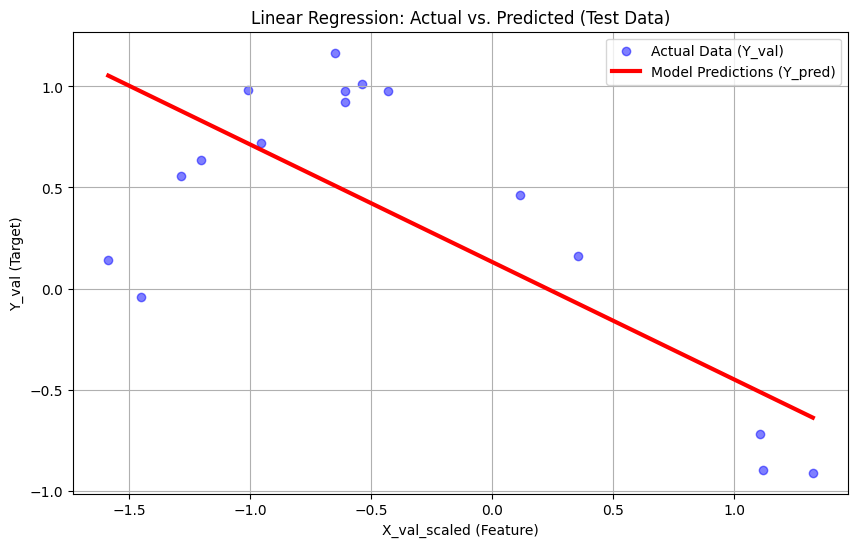

In [26]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, Y_train)

Y_pred = linear_model.predict(X_val_scaled)

mse = mean_squared_error(Y_val, Y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(Y_val, Y_pred)

print("\n--- Linear Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

plt.figure(figsize=(10, 6))

plt.scatter(X_val_scaled, Y_val, color='blue', alpha=0.5, label='Actual Data (Y_val)')

sorted_indices = np.argsort(X_val_scaled, axis=0).flatten()
X_test_sorted = X_val_scaled[sorted_indices]
Y_pred_sorted = Y_pred[sorted_indices]

plt.plot(X_test_sorted, Y_pred_sorted, color='red', linewidth=3, label='Model Predictions (Y_pred)')

plt.title("Linear Regression: Actual vs. Predicted (Test Data)")
plt.xlabel("X_val_scaled (Feature)")
plt.ylabel("Y_val (Target)")
plt.legend()
plt.grid(True)
plt.show()


The closed-form solution calculates optimal weights $\theta$ in one step:

$$ \theta = (X^T X)^{-1} X^T y $$

Computational Bottleneck ($n$ datapoints, $m$ features):

$X^T X$ Multiplication: $O(n \cdot m^2)$
Matrix Inversion: $O(m^3)$

The Normal Equation scales cubically with the number of features ($O(m^3)$). For datasets with thousands of features, inverting the matrix becomes computationally impossible, making iterative methods like Gradient Descent essential.

## Polynomial Regresssion

Degree   2 | Train RMSE: 0.2627 | Val RMSE: 0.2614
Degree   3 | Train RMSE: 0.1393 | Val RMSE: 0.1265
Degree   5 | Train RMSE: 0.1292 | Val RMSE: 0.1117
Degree   7 | Train RMSE: 0.1285 | Val RMSE: 0.1143
Degree  10 | Train RMSE: 0.1283 | Val RMSE: 0.1193
Degree  13 | Train RMSE: 0.1270 | Val RMSE: 0.1210
Degree  16 | Train RMSE: 0.1253 | Val RMSE: 0.2803
Degree  30 | Train RMSE: 0.1049 | Val RMSE: 59.3301
Degree  40 | Train RMSE: 0.1640 | Val RMSE: 798.0162
Degree  50 | Train RMSE: 0.1080 | Val RMSE: 7504.1982


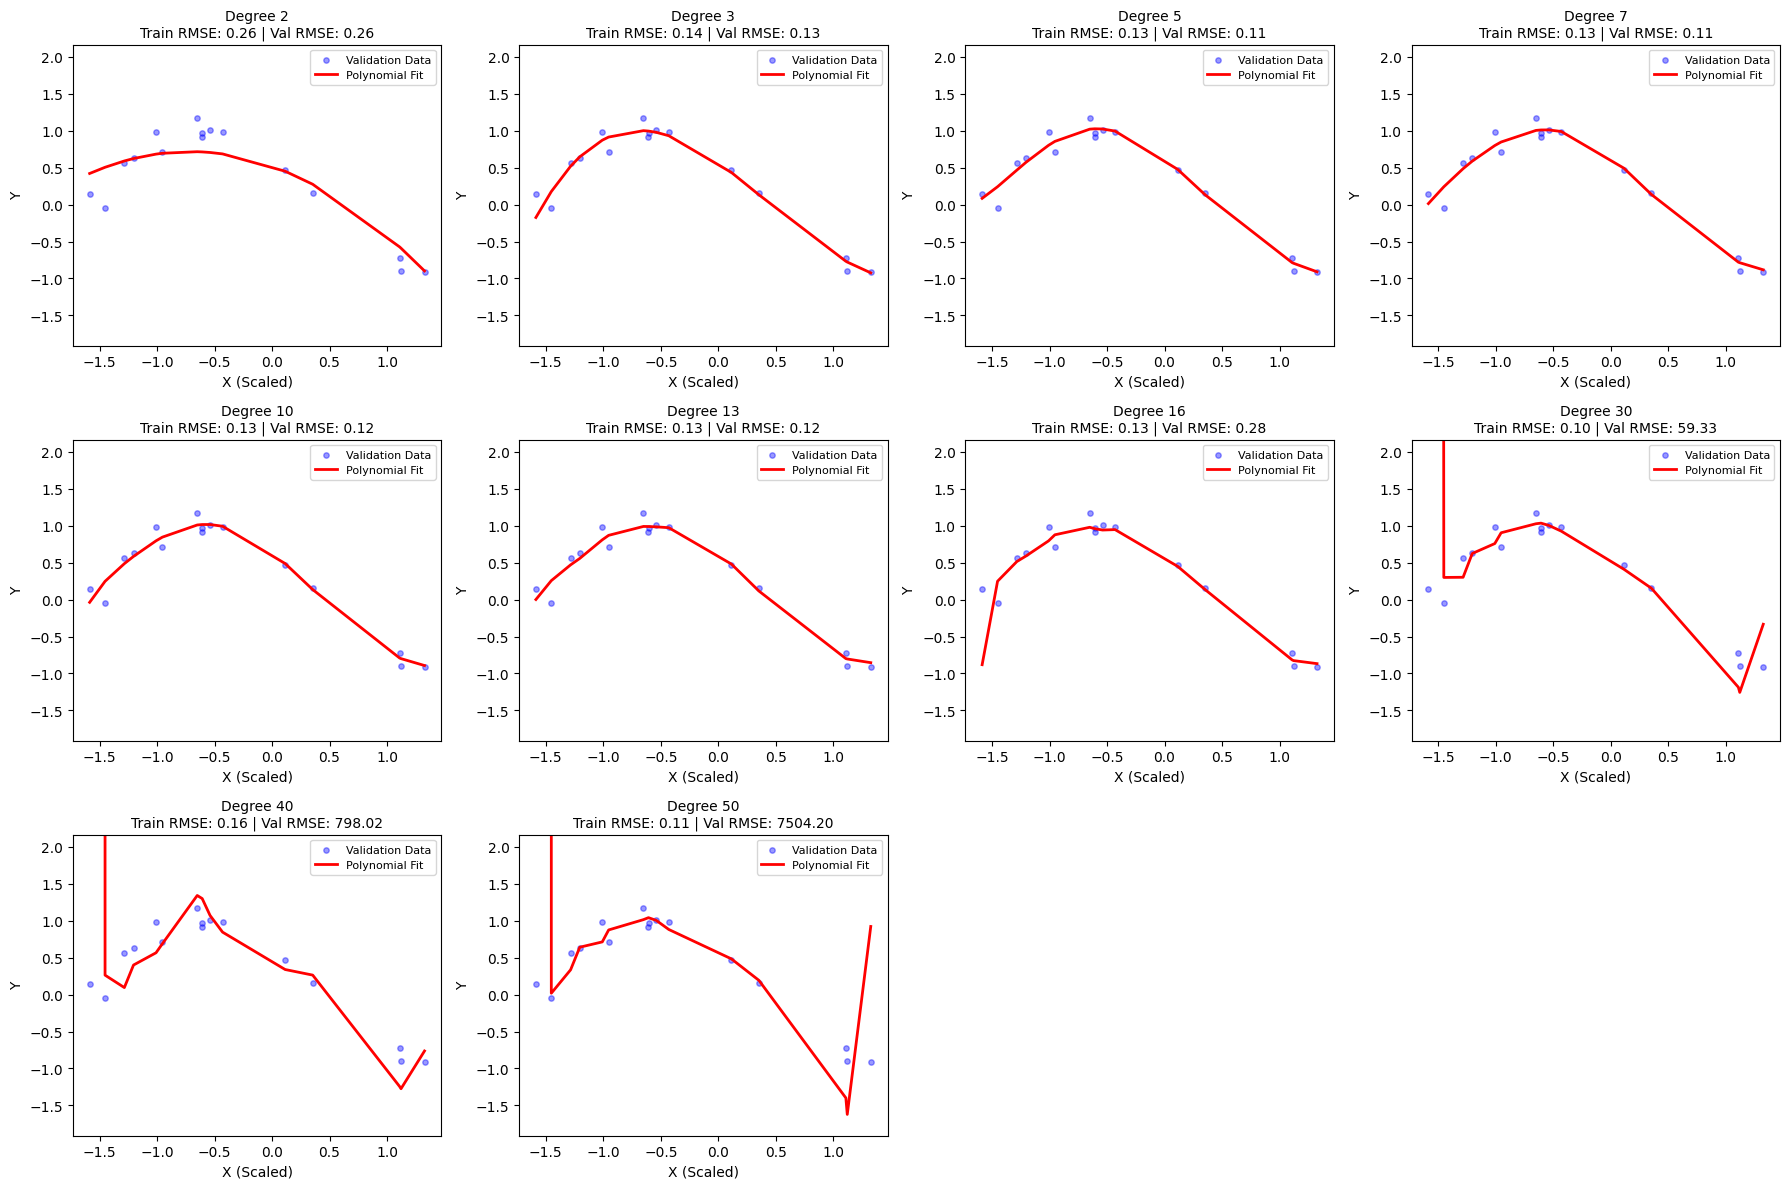

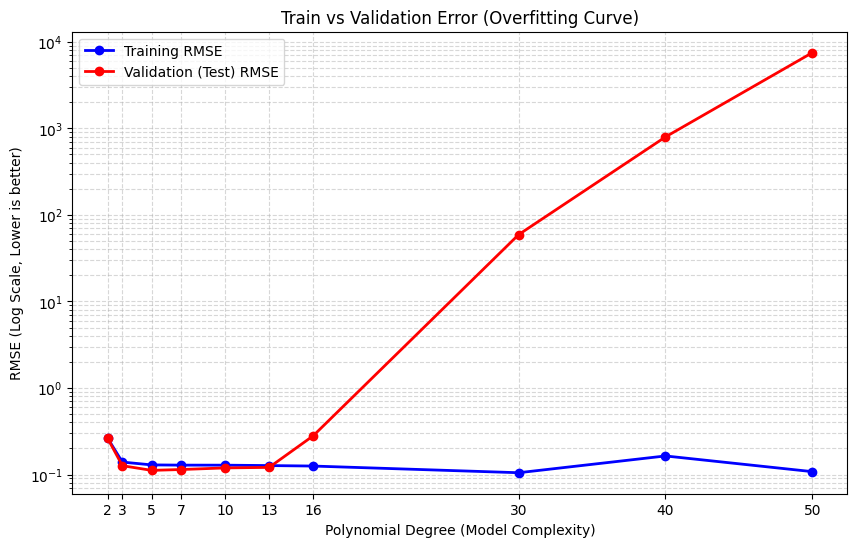

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

degrees = [2, 3, 5, 7, 10, 13, 16, 30, 40, 50]

# Lists to store our metrics for the final summary plot
train_rmses = []
val_rmses = []

# Dynamically calculate rows and columns (fixing cols to 4)
num_degrees = len(degrees)
num_cols = 4
num_rows = (num_degrees + num_cols - 1) // num_cols

# Setup the grid for subplots, scaling height dynamically based on num_rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))

# Flatten the axes array to easily iterate over it
axes = axes.flatten()

for i, degree in enumerate(degrees):
    ax = axes[i]

    # Initialize and train the model
    poly_model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear_reg', LinearRegression())
    ])
    poly_model.fit(X_train_scaled, Y_train)
    
    # Predict and evaluate on TRAINING data
    Y_train_pred = poly_model.predict(X_train_scaled)
    train_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    train_rmses.append(train_rmse)

    # Predict and evaluate on VALIDATION data
    Y_val_pred = poly_model.predict(X_val_scaled)
    val_rmse = np.sqrt(mean_squared_error(Y_val, Y_val_pred))
    val_rmses.append(val_rmse)

    print(f"Degree {degree:3d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

    # --- Plotting the Fit on the Subplot ---
    # We sort the validation data so the line plots smoothly without zigzagging
    sorted_idx = np.argsort(X_val_scaled, axis=0).flatten()
    
    # Scatter actual validation points
    ax.scatter(X_val_scaled, Y_val, color='blue', alpha=0.4, s=15, label="Validation Data")
    # Plot the predicted curve
    ax.plot(X_val_scaled[sorted_idx], Y_val_pred[sorted_idx], color='red', linewidth=2, label="Polynomial Fit")
    
    # Formatting the subplot
    ax.set_title(f"Degree {degree}\nTrain RMSE: {train_rmse:.2f} | Val RMSE: {val_rmse:.2f}", fontsize=10)
    ax.set_xlabel("X (Scaled)")
    ax.set_ylabel("Y")
    ax.legend(fontsize=8)
    
    # Let's cap the Y-axis so the plot remains readable based on validation data
    ax.set_ylim(min(Y_val) - 1, max(Y_val) + 1)

# Hide any unused subplots (e.g., if we have 10 degrees but a 3x4 grid = 12 spots)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Clean up layout and display the grid
plt.tight_layout()
plt.show()

# Training vs Validation Metrics (Overfitting Curve)
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmses, marker='o', color='blue', linewidth=2, label='Training RMSE')
plt.plot(degrees, val_rmses, marker='o', color='red', linewidth=2, label='Validation (Test) RMSE')
plt.title("Train vs Validation Error (Overfitting Curve)")
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("RMSE (Log Scale, Lower is better)")
plt.xticks(degrees)
# Use a logarithmic scale for the Y-axis to handle massive validation errors
plt.yscale('log') 
plt.legend()
# Make the grid show up for both major and minor ticks on the log scale
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


As we can see the model starts overfitting to the training data i.e. validation metrics start to decrease, as we increase the degree of the polynomial regression.

## Regularised Linear Regression Models

As seen above polynomial regressions increases the number of features on which we need to train our model i.e. m, so it is computationally expensive. Hence we move to regularisation.

### Ridge Regression


--- Polynomial Ridge Regression (Degree 30) ---
Mean Squared Error (MSE): 0.02
Root Mean Squared Error (RMSE): 0.13
R-squared (R2) Score: 0.9613

--- Non-Regularised Polynomial Regression (Degree 30) ---
Mean Squared Error (MSE): 3520.02
Root Mean Squared Error (RMSE): 59.33
R-squared (R2) Score: -7614.1504


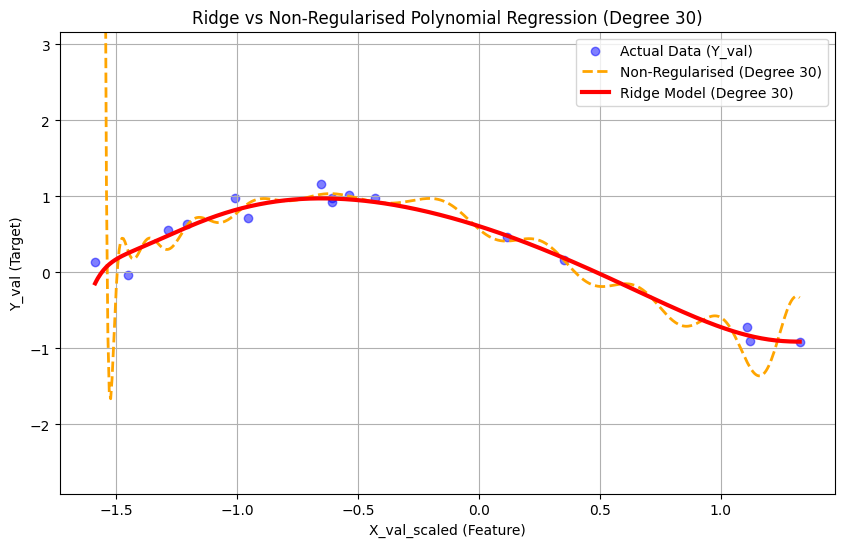

In [28]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

degree = 30

# 1. Regularised (Ridge) Model
ridge_poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge_reg', Ridge(alpha=0.25)) 
])

# 2. Non-Regularised (Standard Linear Regression) Model
non_regularised_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear_reg', LinearRegression()) 
])

# Train both models
ridge_poly_model.fit(X_train_scaled, Y_train)
non_regularised_model.fit(X_train_scaled, Y_train)

# --- Evaluate Ridge Model ---
Y_pred_ridge = ridge_poly_model.predict(X_val_scaled)
mse_ridge = mean_squared_error(Y_val, Y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge) 
r2_ridge = r2_score(Y_val, Y_pred_ridge)

print(f"\n--- Polynomial Ridge Regression (Degree {degree}) ---")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"R-squared (R2) Score: {r2_ridge:.4f}")

# --- Evaluate Non-Regularised Model ---
Y_pred_unreg = non_regularised_model.predict(X_val_scaled)
mse_unreg = mean_squared_error(Y_val, Y_pred_unreg)
rmse_unreg = np.sqrt(mse_unreg) 
r2_unreg = r2_score(Y_val, Y_pred_unreg)

print(f"\n--- Non-Regularised Polynomial Regression (Degree {degree}) ---")
print(f"Mean Squared Error (MSE): {mse_unreg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_unreg:.2f}")
print(f"R-squared (R2) Score: {r2_unreg:.4f}")

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Scatter the actual validation points
plt.scatter(X_val_scaled, Y_val, color='blue', alpha=0.5, label='Actual Data (Y_val)')

# Generate dense points for plotting smooth curves
X_line = np.linspace(X_val_scaled.min(), X_val_scaled.max(), 500).reshape(-1, 1)

# Predict curves for both models
Y_line_pred_ridge = ridge_poly_model.predict(X_line)
Y_line_pred_unreg = non_regularised_model.predict(X_line)

# Plot both curves
# Non-regularised model plotted with an orange dashed line
plt.plot(X_line, Y_line_pred_unreg, color='orange', linewidth=2, linestyle='--', label=f'Non-Regularised (Degree {degree})')
# Ridge model plotted with a solid red line
plt.plot(X_line, Y_line_pred_ridge, color='red', linewidth=3, label=f'Ridge Model (Degree {degree})')

plt.title(f"Ridge vs Non-Regularised Polynomial Regression (Degree {degree})")
plt.xlabel("X_val_scaled (Feature)")
plt.ylabel("Y_val (Target)")

# Cap the Y-axis so the unregularised curve doesn't ruin the plot scale at the edges
plt.ylim(min(Y_val) - 2, max(Y_val) + 2)

plt.legend()
plt.grid(True)
plt.show()


### Lasso Regression


--- Polynomial Lasso Regression (Degree 30) ---
RMSE: 0.26 | R2: 0.8511
Features kept: 3 out of 30

--- Non-Regularised Polynomial Regression (Degree 30) ---
RMSE: 59.33 | R2: -7614.1504


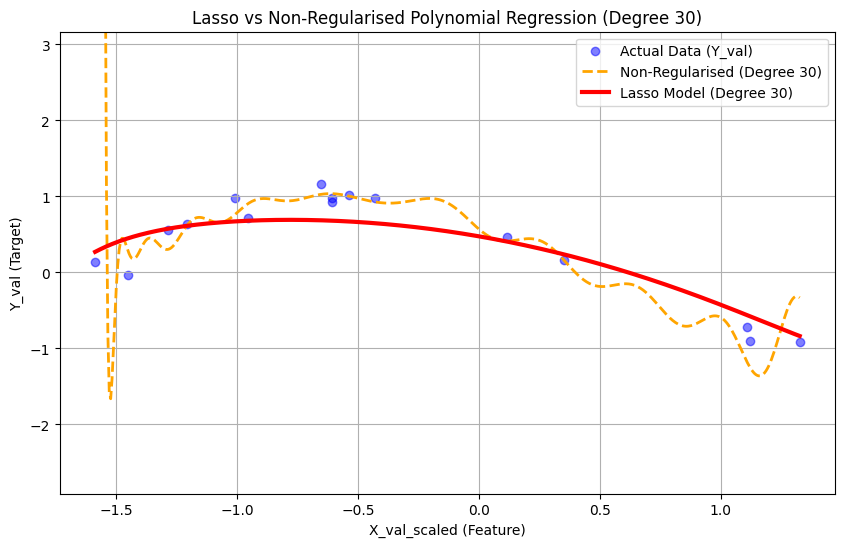

In [29]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

degree = 30

# 1. Regularised (Lasso) Model
lasso_poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso_reg', Lasso(alpha=0.05, max_iter=10000)) # Increased max_iter for convergence
])

# 2. Non-Regularised (Standard Linear Regression) Model
non_regularised_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear_reg', LinearRegression()) 
])

# Train both models
lasso_poly_model.fit(X_train_scaled, Y_train)
non_regularised_model.fit(X_train_scaled, Y_train)

# --- Evaluate Lasso Model ---
Y_pred_lasso = lasso_poly_model.predict(X_val_scaled)
mse_lasso = mean_squared_error(Y_val, Y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso) 
r2_lasso = r2_score(Y_val, Y_pred_lasso)

print(f"\n--- Polynomial Lasso Regression (Degree {degree}) ---")
print(f"RMSE: {rmse_lasso:.2f} | R2: {r2_lasso:.4f}")

# Check how many features Lasso completely removed
lasso_step = lasso_poly_model.named_steps['lasso_reg']
features_kept = np.sum(lasso_step.coef_ != 0)
print(f"Features kept: {features_kept} out of {len(lasso_step.coef_)}")

# --- Evaluate Non-Regularised Model ---
Y_pred_unreg = non_regularised_model.predict(X_val_scaled)
mse_unreg = mean_squared_error(Y_val, Y_pred_unreg)
rmse_unreg = np.sqrt(mse_unreg) 
r2_unreg = r2_score(Y_val, Y_pred_unreg)

print(f"\n--- Non-Regularised Polynomial Regression (Degree {degree}) ---")
print(f"RMSE: {rmse_unreg:.2f} | R2: {r2_unreg:.4f}")


# --- Plotting ---
plt.figure(figsize=(10, 6))

# Scatter the actual validation points
plt.scatter(X_val_scaled, Y_val, color='blue', alpha=0.5, label='Actual Data (Y_val)')

# Generate dense points for plotting smooth curves
X_line = np.linspace(X_val_scaled.min(), X_val_scaled.max(), 500).reshape(-1, 1)

# Predict curves for both models
Y_line_pred_lasso = lasso_poly_model.predict(X_line)
Y_line_pred_unreg = non_regularised_model.predict(X_line)

# Plot both curves
# Non-regularised model plotted with an orange dashed line
plt.plot(X_line, Y_line_pred_unreg, color='orange', linewidth=2, linestyle='--', label=f'Non-Regularised (Degree {degree})')
# Lasso model plotted with a solid red line
plt.plot(X_line, Y_line_pred_lasso, color='red', linewidth=3, label=f'Lasso Model (Degree {degree})')

plt.title(f"Lasso vs Non-Regularised Polynomial Regression (Degree {degree})")
plt.xlabel("X_val_scaled (Feature)")
plt.ylabel("Y_val (Target)")

# Cap the Y-axis so the explosive non-regularised curve doesn't ruin the plot scale
plt.ylim(min(Y_val) - 2, max(Y_val) + 2)

plt.legend()
plt.grid(True)
plt.show()


### Elastic Net Regression


--- Polynomial ElasticNet Regression (Degree 30) ---
Mean Squared Error (MSE): 0.03
Root Mean Squared Error (RMSE): 0.18
R-squared (R2) Score: 0.9336
Features kept: 14 out of 30

--- Non-Regularised Polynomial Regression (Degree 30) ---
Mean Squared Error (MSE): 3520.02
Root Mean Squared Error (RMSE): 59.33
R-squared (R2) Score: -7614.1504


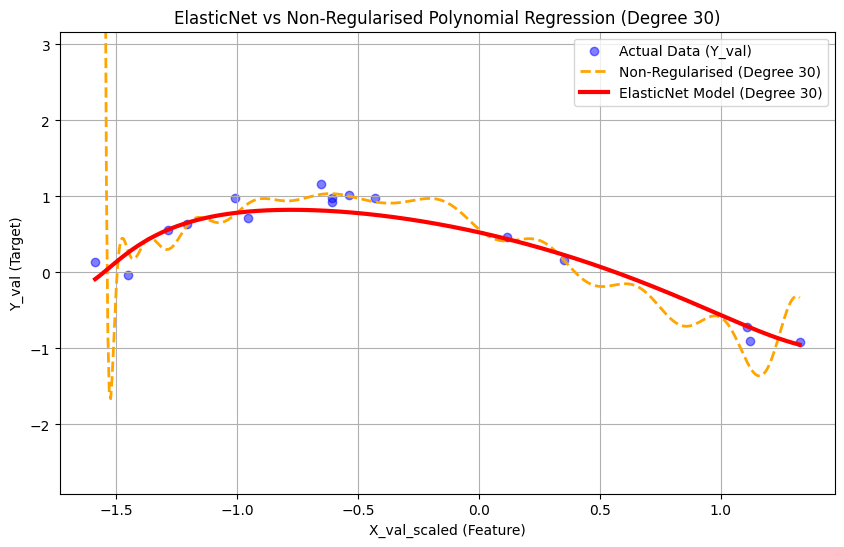

In [30]:
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

degree = 30

# 1. Regularised (ElasticNet) Model
elastic_poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('elastic_reg', ElasticNet(alpha=0.05, l1_ratio=0.05, max_iter=10000)) 
])

# 2. Non-Regularised (Standard Linear Regression) Model
non_regularised_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear_reg', LinearRegression()) 
])

# Train both models
elastic_poly_model.fit(X_train_scaled, Y_train)
non_regularised_model.fit(X_train_scaled, Y_train)

# --- Evaluate ElasticNet Model ---
Y_pred_elastic = elastic_poly_model.predict(X_val_scaled)
mse_elastic = mean_squared_error(Y_val, Y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic) 
r2_elastic = r2_score(Y_val, Y_pred_elastic)

print(f"\n--- Polynomial ElasticNet Regression (Degree {degree}) ---")
print(f"Mean Squared Error (MSE): {mse_elastic:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_elastic:.2f}")
print(f"R-squared (R2) Score: {r2_elastic:.4f}")

# Check how many features ElasticNet completely removed (thanks to its Lasso component!)
elastic_step = elastic_poly_model.named_steps['elastic_reg']
features_kept = np.sum(elastic_step.coef_ != 0)
print(f"Features kept: {features_kept} out of {len(elastic_step.coef_)}")

# --- Evaluate Non-Regularised Model ---
Y_pred_unreg = non_regularised_model.predict(X_val_scaled)
mse_unreg = mean_squared_error(Y_val, Y_pred_unreg)
rmse_unreg = np.sqrt(mse_unreg) 
r2_unreg = r2_score(Y_val, Y_pred_unreg)

print(f"\n--- Non-Regularised Polynomial Regression (Degree {degree}) ---")
print(f"Mean Squared Error (MSE): {mse_unreg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_unreg:.2f}")
print(f"R-squared (R2) Score: {r2_unreg:.4f}")


# --- Plotting ---
plt.figure(figsize=(10, 6))

# Scatter the actual validation points
plt.scatter(X_val_scaled, Y_val, color='blue', alpha=0.5, label='Actual Data (Y_val)')

# Generate dense points for plotting smooth curves
X_line = np.linspace(X_val_scaled.min(), X_val_scaled.max(), 500).reshape(-1, 1)

# Predict curves for both models
Y_line_pred_elastic = elastic_poly_model.predict(X_line)
Y_line_pred_unreg = non_regularised_model.predict(X_line)

# Plot both curves
# Non-regularised model plotted with an orange dashed line
plt.plot(X_line, Y_line_pred_unreg, color='orange', linewidth=2, linestyle='--', label=f'Non-Regularised (Degree {degree})')
# ElasticNet model plotted with a solid red line
plt.plot(X_line, Y_line_pred_elastic, color='red', linewidth=3, label=f'ElasticNet Model (Degree {degree})')

plt.title(f"ElasticNet vs Non-Regularised Polynomial Regression (Degree {degree})")
plt.xlabel("X_val_scaled (Feature)")
plt.ylabel("Y_val (Target)")

# Cap the Y-axis so the unregularised curve doesn't ruin the plot scale at the edges
plt.ylim(min(Y_val) - 2, max(Y_val) + 2)

plt.legend()
plt.grid(True)
plt.show()

> 💡 Try to play around with the hyperparameters ```degree```, ```alpha``` and ```l1_ratio``` and observe how the curve, metrics change. 

## Let's try out the models on the dataset we processed previously

> **NOTE**: Since these are linear models, the scale of features matters very much. So standardising the features is a must.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('processed_data.csv')
target_column = "median_house_value"

print(f'Total number of datapoints: {len(df)}')
print(f'Number of input columns: {len(df.columns)-1}')
print(f"Feature columns: {list(df.columns.drop(target_column))}")
print(f'Target Column = {target_column}')

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Total number of datapoints: 20640
Number of input columns: 14
Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'total_rooms_log', 'total_bedrooms_log', 'population_log', 'households_log', 'median_income_log']
Target Column = median_house_value


In [32]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("\n--- Linear Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Linear Regression Model Evaluation ---
Mean Squared Error (MSE): 4926838151.42
Root Mean Squared Error (RMSE): 70191.44
R-squared (R2) Score: 0.6240


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

degree = 2

poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=True)),
    ('scaler', StandardScaler()),
    ('linear_reg', LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_val, y_pred)

print(f"\n--- Polynomial Regression (Degree {degree}) Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Polynomial Regression (Degree 2) Evaluation ---
Mean Squared Error (MSE): 8974752951.28
Root Mean Squared Error (RMSE): 94735.17
R-squared (R2) Score: 0.3151


Polynomial Regression takes your existing data columns and creates many new ones by squaring, cubing, and multiplying them together. It then simply runs a standard linear regression on this massive new set of features to capture curved relationships.

In [34]:
from sklearn.linear_model import Ridge

degree = 2

ridge_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=True)),
    ('scaler', StandardScaler()),
    ('linear_reg', Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("\n--- Ridge Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Ridge Regression Model Evaluation ---
Mean Squared Error (MSE): 4030287012.65
Root Mean Squared Error (RMSE): 63484.54
R-squared (R2) Score: 0.6924


In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

degree = 2

# alpha controls the strength of the regularization (higher = more features dropped to 0)
lasso_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=True)),
    ('scaler', StandardScaler()),
    ('linear_reg', Lasso(alpha=1.0))
])

lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_val)


mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_val, y_pred)

print("\n--- Lasso Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# See how many features Lasso completely removed
lasso_step = lasso_model.named_steps['linear_reg']
features_kept = np.sum(lasso_step.coef_ != 0)
print(f"Features kept: {features_kept} out of {len(lasso_step.coef_)}")


--- Lasso Regression Model Evaluation ---
Mean Squared Error (MSE): 4061285317.64
Root Mean Squared Error (RMSE): 63728.21
R-squared (R2) Score: 0.6901
Features kept: 119 out of 120


c:\Users\srira\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.751e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

degree = 2

# alpha: Overall strength of the regularization
# l1_ratio: The mix between Lasso (L1) and Ridge (L2). 0.5 means a 50/50 mix.
elastic_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=True)),
    ('scaler', StandardScaler()),
    ('linear_reg', ElasticNet(alpha=1.0, l1_ratio=0.5))
])

elastic_model.fit(X_train, y_train)
y_pred = elastic_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_val, y_pred)

print("\n--- ElasticNet Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- ElasticNet Regression Model Evaluation ---
Mean Squared Error (MSE): 4617051422.82
Root Mean Squared Error (RMSE): 67948.89
R-squared (R2) Score: 0.6477


> 💡 `ElasticNet` or `Lasso` or `Ridge` is applied after applying the ```PolynomialFeatures``` function on the data, otherwise we are just regularising on plain old 1-degree linear regression features